# 1. Split

from sklearn.model_selection import 

In [35]:
import warnings
from sklearn.exceptions import FitFailedWarning

# Suppress FutureWarnings and FitFailedWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [37]:
df = pd.read_csv('data/clean_data_v1.csv')
df = df.drop(columns=["Unnamed: 0", "RowNumber", "CustomerId"])
df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [38]:
X = df.iloc[:,:-1]
y = df.iloc[:, -1]

X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64
9996,516,0,1,35,10,57369.61,1,1,1,101699.77
9997,709,0,0,36,7,0.00,1,0,1,42085.58
9998,772,1,1,42,3,75075.31,2,1,0,92888.52


In [39]:
TRAINING_SIZE = 0.8
RANDOM_STATE = 42

In [40]:
x_train_unbalanced, x_temp, y_train_unbalanced, y_temp = train_test_split(X, y, train_size=TRAINING_SIZE, random_state=RANDOM_STATE, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

print(len(x_train_unbalanced))
print(len(x_val))
print(len(x_test))

8000
1000
1000


# Balancing Training Dataset 

<Axes: >

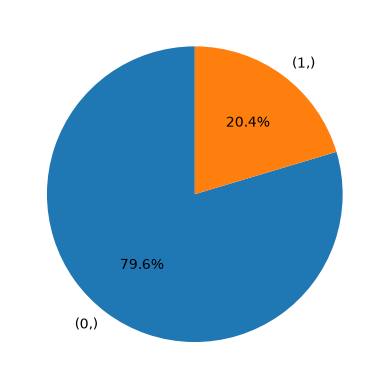

In [41]:
pd.DataFrame(y_train_unbalanced).value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)

In [42]:
x_train = x_train_unbalanced
y_train = y_train_unbalanced

In [43]:
# # train_df = pd.DataFrame(x_train_unbalanced)
# # train_df['target'] = y_train_unbalanced

# # df_exited = train_df[train_df['target']==1]
# # df_not_exited = train_df[train_df['target']==0]

# # print("Before Balancing")
# # display(train_df['target'].describe())

# # df_not_exited = df_not_exited.sample(n=len(df_exited), random_state=RANDOM_STATE)
# # train_df = pd.concat([df_exited, df_not_exited])

# # print("="*50)
# # print("After Balancing")
# # display(train_df['target'].describe())

# x_train = train_df.iloc[:,:-1]
# y_train = train_df.iloc[:,-1]

# 2. Training 

In [44]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, recall_score, precision_score, RocCurveDisplay, roc_curve

# Imbalance Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [45]:
def display_metric(y_true, y_pred, name=None, ConfusionMatrix=True):


    f1 = f1_score(y_true=y_true, y_pred=y_pred)
    recall = recall_score(y_true=y_true, y_pred=y_pred)
    precision = precision_score(y_true=y_true, y_pred=y_pred)

    print("f1_score:", f"%{round(f1*100,4)}")
    print("recall_score:", f"%{round(recall*100,4)}")
    print("precision_score:", f"%{round(precision*100,4)}")

    

    if ConfusionMatrix:
        if name:
            plt.title(name)
        ConfusionMatrixDisplay.from_predictions(y_true=y_true, y_pred=y_pred)
    print("-"*50)

    return f1, recall, precision


    

In [46]:
def get_best_threshold(y_test, y_pred, printing=True):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)

    best_threshold = thresholds[best_idx]
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]

    if printing:
        print(f"Optimal Threshold: {best_threshold:.4f}")
        print(f"At this threshold -> TPR (Recall): {best_tpr:.4f}, FPR: {best_fpr:.4f}")

    return best_threshold


### 2.1 Logisitic Regression

In [47]:
def get_logisitic_regression():
    first_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        # ("polynomial",PolynomialFeatures(degree=3)),
        ('classifier', LogisticRegression(random_state=RANDOM_STATE))
    ])

    params_grid = {
        "classifier__C":[0.01, 0.1, 1, 10],
        "classifier__penalty":["l1", "l2"],
        "classifier__solver":["liblinear", "newton-cg", "sag"],
        'classifier__class_weight': ['balanced']
    }

    gridSearch = GridSearchCV(estimator=first_pipeline, param_grid=params_grid, cv=5, scoring="accuracy", n_jobs=-1)
    gridSearch.fit(x_train, y_train)

    return gridSearch

f1_score: %50.8306
recall_score: %75.0
precision_score: %38.4422
--------------------------------------------------


(0.5083056478405316, 0.75, 0.3844221105527638)

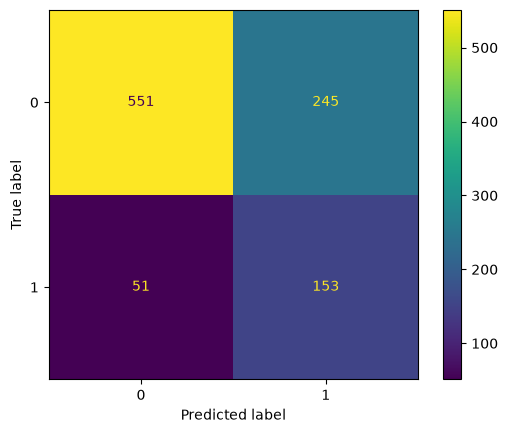

In [48]:
logistic_model = get_logisitic_regression()
y_val_pred = logistic_model.predict(x_val)
display_metric(y_val, y_val_pred)

### 2.2 Random Forest

In [49]:
def get_random_forest():
    # first_pipeline = Pipeline([
    #     ("scaler", StandardScaler()),
    #     ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
    # ])

    pipe = ImbPipeline([
        ("scaler", StandardScaler()),
        # ("smote", SMOTE(random_state=RANDOM_STATE)),
        # ("polynomial",PolynomialFeatures(degree=3)),
        ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
    ])


    params_grid = {
        "classifier__n_estimators":[200, 300],
        "classifier__max_depth":[10, 30],
        'classifier__class_weight': ['balanced']
    }

    gridSearch = GridSearchCV(estimator=pipe, param_grid=params_grid, cv=5, scoring="accuracy")
    gridSearch.fit(x_train, y_train)

    return gridSearch

In [50]:
random_forest_model = get_random_forest()
rf_pred_y_val = random_forest_model.predict(x_val)
rf_pred_y_val_proba = random_forest_model.predict_proba(x_val)

f1_score: %61.9647
recall_score: %60.2941
precision_score: %63.7306
--------------------------------------------------


(0.6196473551637279, 0.6029411764705882, 0.6373056994818653)

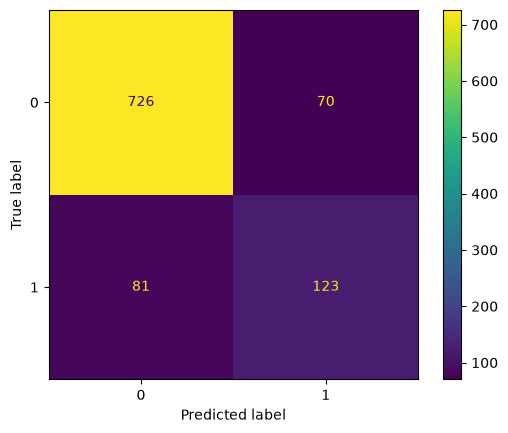

In [51]:
rf_pred_y_val_proba.shape

# for a in rf_pred_y_val_proba:
y_pred_custom = (rf_pred_y_val_proba[:, 1] >= 0.2127).astype(int)
display_metric(y_val, rf_pred_y_val)

### 2.3 SVM

In [ ]:
# with open(f"models/{name}_model_2.pkl", "wb") as f:
#     pickle.dump(model.best_estimator_, f)

NameError: name 'name' is not defined

In [ ]:
def get_svm():
    # first_pipeline = Pipeline([
    #     ("scaler", StandardScaler()),
    #     ('classifier', SVC(random_state=RANDOM_STATE, probability=True))
    # ])
    pipe = ImbPipeline([
        ("scaler", StandardScaler()),
        # ("polynomial",PolynomialFeatures(degree=3)),
        ("classifier", SVC(random_state=RANDOM_STATE, probability=True))
    ])

    params_grid = {
        "classifier__C":[0.01, 0.1, 1, 10],
        'classifier__class_weight': ['balanced'],
        # 'classifier__gamma': ['scale', 'auto', 0.1, 0.01],
        'classifier__kernel':['linear']
        # "classifier__penalty":["l1", "l2"],
        # "classifier__solver":["liblinear", "newton-cg", "sag"]
    }

    gridSearch = GridSearchCV(estimator=pipe, param_grid=params_grid, cv=5, scoring="accuracy")
    gridSearch.fit(x_train, y_train)

    return gridSearch

In [ ]:
svm_model = get_svm()

In [ ]:
svm_pred_y_val = svm_model.predict(x_val)
svm_pred_y_val_proba = svm_model.predict_proba(x_val)

f1_score: %58.1614
recall_score: %75.9804
precision_score: %47.1125
--------------------------------------------------


(0.5816135084427767, 0.7598039215686274, 0.47112462006079026)

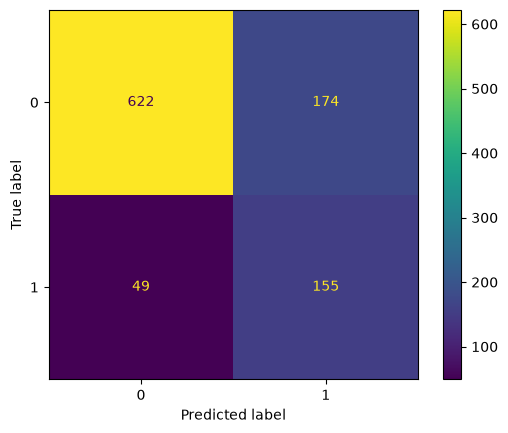

In [ ]:
display_metric(y_val, svm_pred_y_val)

In [ ]:
get_best_threshold(y_val, svm_pred_y_val_proba[:,1])

Optimal Threshold: 0.3213
At this threshold -> TPR (Recall): 0.6912, FPR: 0.1294


np.float64(0.3213227787783676)

f1_score: %57.4506
recall_score: %78.4314
precision_score: %45.3258
--------------------------------------------------
f1_score: %59.4444
recall_score: %52.451
precision_score: %68.5897
--------------------------------------------------


(0.5944444444444444, 0.5245098039215687, 0.6858974358974359)

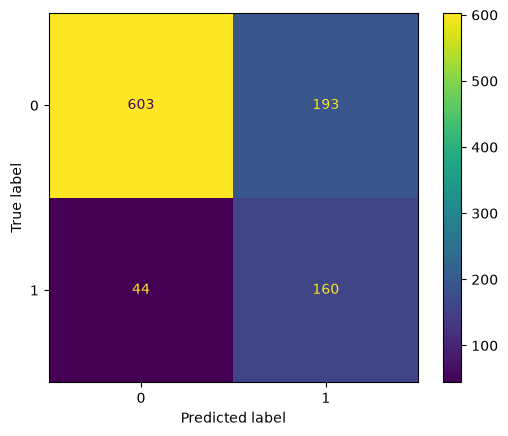

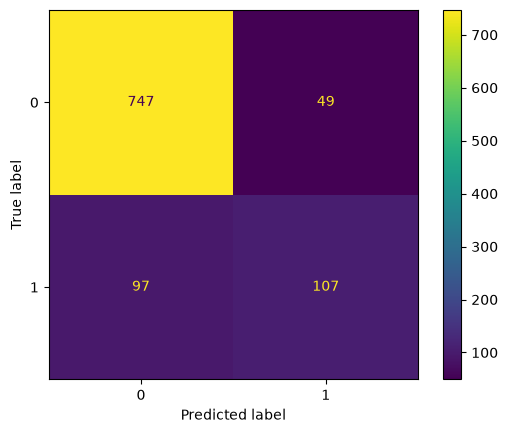

In [ ]:
svm_pred_y_val

predictions = (svm_pred_y_val_proba[:,1] >= 0.1908).astype(int)
display_metric(y_val, predictions)

predictions = (svm_pred_y_val_proba[:,1] >= 0.5).astype(int)
display_metric(y_val, predictions)

# 2.4 Decision Tree

In [ ]:
def get_tree():
    first_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])

    params_grid = {
        # "classifier__C":[0.01, 0.1, 1],
        # "classifier__penalty":["l1", "l2"],
        # "classifier__solver":["liblinear", "newton-cg", "sag"]
        'classifier__class_weight': ['balanced', None]
    }

    gridSearch = GridSearchCV(estimator=first_pipeline, param_grid=params_grid, cv=5, scoring="accuracy")
    gridSearch.fit(x_train, y_train)

    return gridSearch

In [ ]:
decision_tree = get_tree()

f1_score: %47.2289
recall_score: %48.0392
precision_score: %46.4455
--------------------------------------------------


(0.472289156626506, 0.4803921568627451, 0.46445497630331756)

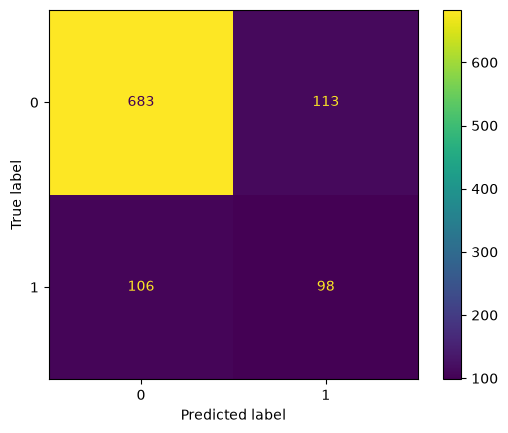

In [ ]:
tree_pred_y_val = decision_tree.predict(x_val)
tree_pred_y_val_proba = decision_tree.predict_proba(x_val)
display_metric(y_val, tree_pred_y_val)

In [ ]:
get_best_threshold(y_val, tree_pred_y_val_proba[:,1])

Optimal Threshold: 1.0000
At this threshold -> TPR (Recall): 0.4804, FPR: 0.1420


np.float64(1.0)

In [ ]:
# display_metric(y_val, rf_pred_y_val)

In [ ]:
# from sklearn.model_selection import TunedThresholdClassifierCV

# # Automatically tune the threshold to maximize F1-score during fitting
# tuned_model = TunedThresholdClassifierCV(
#     estimator=rf.best_estimator_,
#     scoring="f1",
#     cv=5
# )

# tuned_model.fit(x_train, y_train)

# # Calling predict() now uses the automatically tuned threshold instead of 0.5
# y_pred_tuned = tuned_model.predict(x_val)
# display_metric(y_pred_tuned, y_val)

In [ ]:
rf_pred_y_val_proba.shape

(1000, 2)

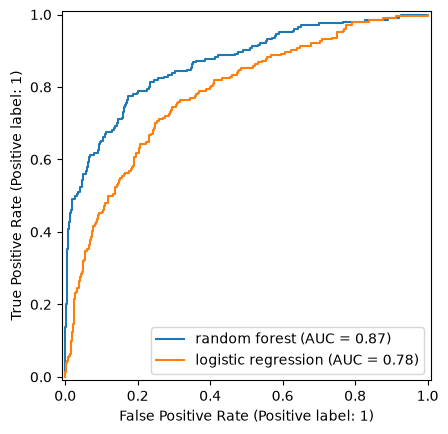

In [ ]:


fig, ax = plt.subplots()

RocCurveDisplay.from_estimator(random_forest_model, x_val, y_val, ax=ax, name="random forest")
RocCurveDisplay.from_estimator(logistic_model, x_val, y_val, ax=ax, name="logistic regression")

plt.show()

# Evaluation

In [53]:
models = {
    "svm":svm_model,
    "logistic_regression": logistic_model,
    "random_forest": random_forest_model,
    "decision_tree": decision_tree
}

NameError: name 'svm_model' is not defined

logistic_regression
f1_score: %58.8889
recall_score: %77.9412
precision_score: %47.3214
--------------------------------------------------
logistic_regression_best_threshold
f1_score: %63.3333
recall_score: %74.5098
precision_score: %55.0725
--------------------------------------------------
random_forest
f1_score: %63.2035
recall_score: %71.5686
precision_score: %56.5891
--------------------------------------------------
random_forest_best_threshold
f1_score: %62.1782
recall_score: %76.9608
precision_score: %52.1595
--------------------------------------------------


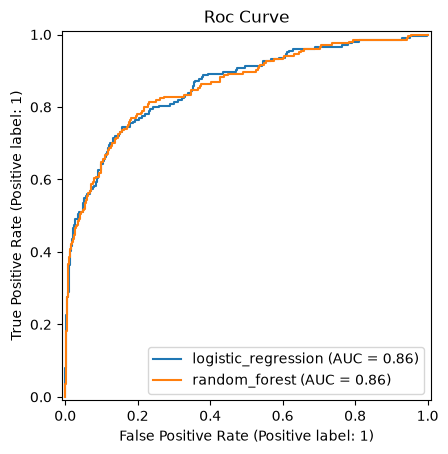

In [ ]:
import pickle

fig, ax = plt.subplots()

data = {
    "Model":[],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

def append_to_data(name, f1, recall, precision):
    data['Model'].append(name)
    data['F1-Score'].append(f1*100)
    data['Recall'].append(recall*100)
    data['Precision'].append(precision*100)


for name, model in models.items():
    y_pred = model.predict(x_val)
    y_pred_probs = model.predict_proba(x_val)[:,1]

    print(name)
    f1, recall, precision = display_metric(y_val, y_pred, ConfusionMatrix=False)
    append_to_data(name, f1, recall, precision)

    name2 = name + "_best_threshold"
    print(name2)
    best_threshold = get_best_threshold(y_val, y_pred_probs, printing=False)
    y_pred_2 = (y_pred_probs >= best_threshold).astype(int)
    f1, recall, precision = display_metric(y_val, y_pred_2, ConfusionMatrix=False)
    append_to_data(name2, f1, recall, precision)

    with open(f"models/{name}_model_2.pkl", "wb") as f:
        pickle.dump(model.best_estimator_, f)

    plt.title("Roc Curve")
    RocCurveDisplay.from_estimator(model, x_val, y_val, ax=ax, name=name)


plt.show()



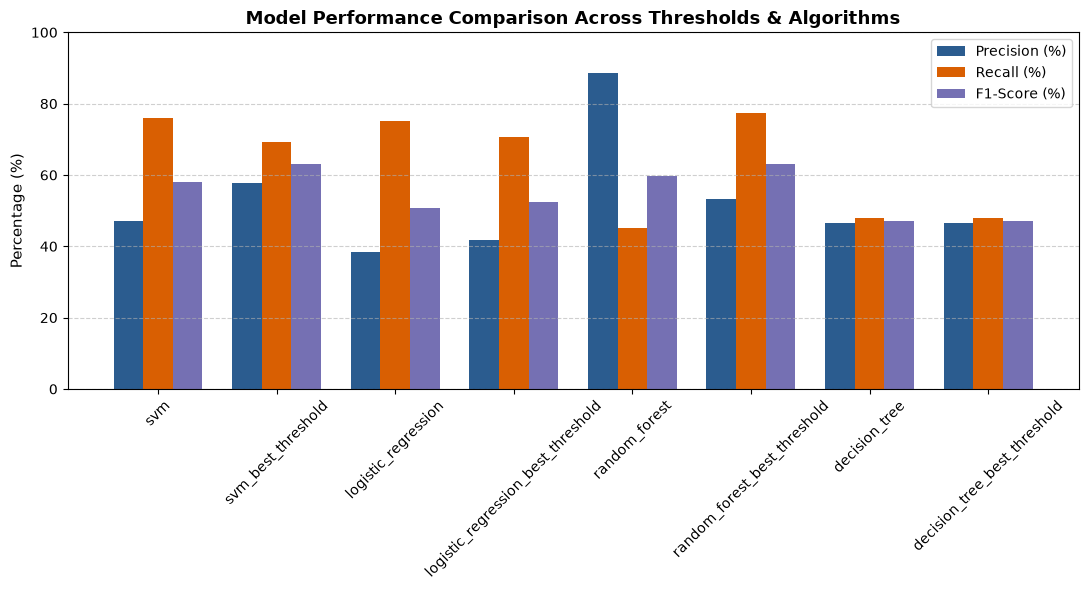

In [ ]:

df = pd.DataFrame(data)


x = np.arange(len(df["Model"]))
width = 0.25

# Create plot
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    x - width,
    df["Precision"],
    width,
    label="Precision (%)",
    color="#2b5c8f",
)
ax.bar(x, df["Recall"], width, label="Recall (%)", color="#d95f02")
ax.bar(
    x + width,
    df["F1-Score"],
    width,
    label="F1-Score (%)",
    color="#7570b3",
)

# Styling
ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_title(
    "Model Performance Comparison Across Thresholds & Algorithms",
    fontsize=13,
    fontweight="bold",
)
plt.xticks(rotation=45)
ax.set_xticks(x)
ax.set_xticklabels(df["Model"], fontsize=10)
ax.set_ylim(0, 100)
ax.legend(frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
file_path = 'models/random_forest_model_2.pkl'
with open(file_path, 'rb') as file:
    loaded_model = pickle.load(file)



In [ ]:
random_forest_model.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
